In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('./Data/advertising.csv')
df

ModuleNotFoundError: No module named 'pandas'

In [2]:
x = df.TV.values.reshape(-1,1)
y = df.Sales.values.reshape(-1,1)

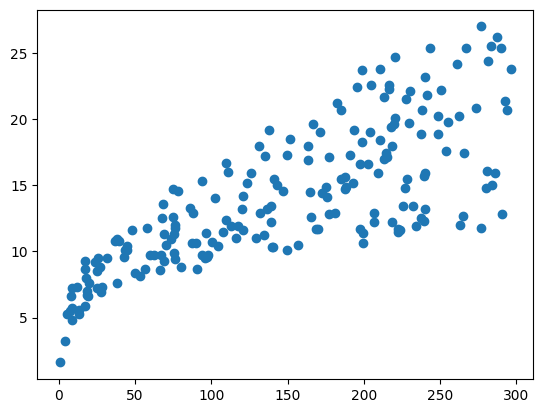

In [3]:
plt.scatter(x,y)
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
model = LinearRegression()
model.fit(x,y)
model.coef_, model.intercept_

(array([[0.04753664]]), array([7.03259355]))

In [5]:
model.score(x,y)

0.611875050850071

In [6]:
y_predict = model.predict(x)
print("MSE = {:.4f}".format(mean_squared_error(y, y_predict)))
print("mAE = {:.4f}".format(mean_absolute_error(y,y_predict)))

MSE = 10.5127
mAE = 2.5498


In [7]:
model.predict([[50]])

array([[9.40942557]])

In [8]:
print('x[i]\t y[i]\t y_predict[i]')
for i in range(len(x[:20])):
    print(x[i][0],' \t',y[i][0],' \t',y_predict[i][0])

x[i]	 y[i]	 y_predict[i]
230.1  	 22.1  	 17.970774512765537
44.5  	 10.4  	 9.147974048397074
17.2  	 9.3  	 7.8502237645756345
151.5  	 18.5  	 14.234394574730187
180.8  	 12.9  	 15.627218139417666
8.7  	 7.2  	 7.446162320894967
57.5  	 11.8  	 9.76595037402633
120.2  	 13.2  	 12.746497729176669
8.6  	 4.8  	 7.441408656851665
199.8  	 10.6  	 16.53041430764504
66.1  	 8.6  	 10.174765481750299
214.7  	 17.4  	 17.238710250097036
23.8  	 9.2  	 8.163965591433564
97.5  	 9.7  	 11.66741599134712
204.1  	 19.0  	 16.734821861507026
195.4  	 22.4  	 16.321253089739756
67.8  	 12.5  	 10.255577770486433
281.4  	 24.4  	 20.40940416697945
69.2  	 11.3  	 10.32212906709266
147.3  	 14.6  	 14.034740684911505


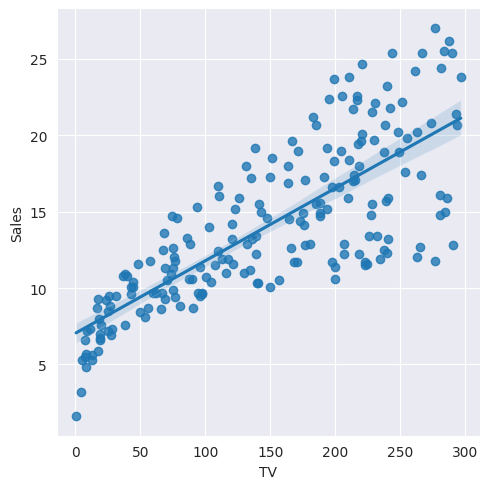

In [9]:
sns.set_style('darkgrid')
sns.lmplot(x='TV', y='Sales', data=df)
plt.show()

In [10]:
x_input = [[300],[500],[1000]]
y_predict = model.predict(x_input)
print(y_predict)

[[21.29358568]
 [30.80091377]
 [54.56923398]]


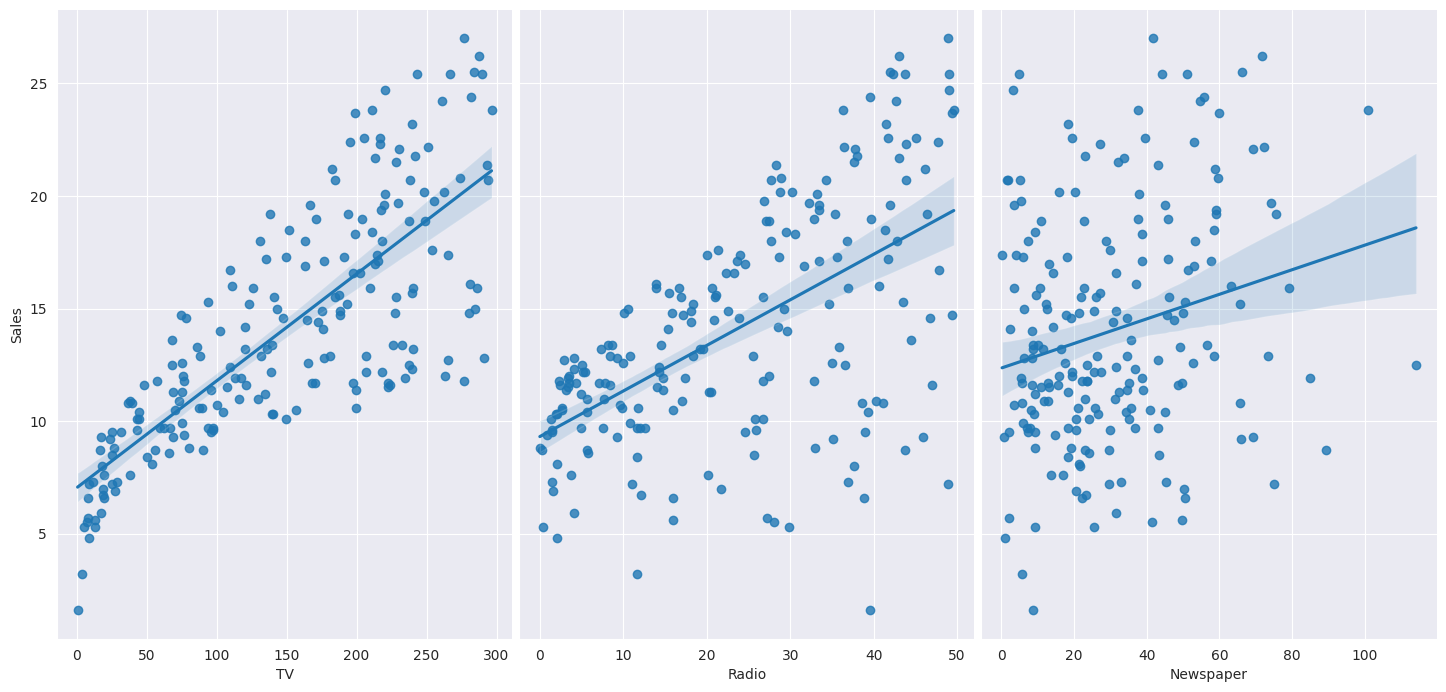

In [12]:
sns.pairplot(df, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', height=7, aspect=0.7, kind='reg')
plt.show()

In [13]:
features = ['TV','Radio','Newspaper']
x = df[features]
y=df.Sales

In [14]:
model = LinearRegression()
model.fit(x.values,y)
print(model.coef_, model.intercept_)

[ 0.04576465  0.18853002 -0.00103749] 2.938889369459412


In [15]:
list(zip(features, model.coef_))

[('TV', np.float64(0.0457646454553976)),
 ('Radio', np.float64(0.18853001691820448)),
 ('Newspaper', np.float64(-0.0010374930424763285))]

In [16]:
df.corr().round(3)

,Unnamed: 0,TV,Radio,Newspaper,Sales
Unnamed: 0,1.000,0.018,-0.111,-0.155,-0.052
TV,0.018,1.000,0.055,0.057,0.782
Radio,-0.111,0.055,1.000,0.354,0.576
Newspaper,-0.155,0.057,0.354,1.000,0.228
Sales,-0.052,0.782,0.576,0.228,1.000


In [17]:
x_input = [[300, 0, 0], [0, 300, 0], [0, 0, 300],[100,200,100],[100,200,0]]
model.predict(x_input)

array([16.66828301, 59.49789444,  2.62764146, 45.11760799, 45.2213573 ])

# ANN Regreesion

In [18]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
model = MLPRegressor(hidden_layer_sizes=(100,100), max_iter=1000, random_state=42)
model.fit(x_train, y_train)
model.score(x_test, y_test)


(160, 3) (160,)
(40, 3) (40,)


/home/night/Git_Hub/study_ai/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


0.8229224352129834

In [20]:
y_predict = model.predict(x_test)
print("MSE = {:.4f}".format(mean_squared_error(y_test, y_predict)))
print("mAE = {:.4f}".format(mean_absolute_error(y_test,y_predict)))

MSE = 5.5892
mAE = 1.5636


# Classification

In [21]:
import pandas as pd
df2 = pd.read_csv("./Data/iris.csv")


In [23]:
class_names = df2['species'].unique()
print(class_names)
df2.isnull().sum()

<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [24]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
x = df2[features]
print(x.head(2))

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2


In [25]:
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(df2.species)
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
model = MLPClassifier(hidden_layer_sizes=(20,3), max_iter=100, random_state=42)
model.fit(x_train, y_train)


/home/night/Git_Hub/study_ai/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(20, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [28]:
y_predict = model.predict(x_test)
print("MSE = {:.4f}".format(mean_squared_error(y_test, y_predict)))
print("mAE = {:.4f}".format(mean_absolute_error(y_test,y_predict)))

MSE = 0.3000
mAE = 0.3000


In [29]:
print("accuracy_score",accuracy_score(y_test, y_predict))
print(classification_report(y_test, y_predict, target_names=class_names))

accuracy_score 0.7
                 precision    recall  f1-score   support

    Iris-setosa       0.67      1.00      0.80        10
Iris-versicolor       0.00      0.00      0.00         9
 Iris-virginica       0.73      1.00      0.85        11

       accuracy                           0.70        30
      macro avg       0.47      0.67      0.55        30
   weighted avg       0.49      0.70      0.58        30



/home/night/Git_Hub/study_ai/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/night/Git_Hub/study_ai/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/night/Git_Hub/study_ai/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [30]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_predict)
print(cm)

[[10  0  0]
 [ 5  0  4]
 [ 0  0 11]]


In [31]:
print("y_test\t y_predict")
for i in range(len(y_test)):
    print(f"{y_test[i]}\t {y_predict[i]}")

y_test	 y_predict
1	 0
0	 0
2	 2
1	 2
1	 0
0	 0
1	 2
2	 2
1	 0
1	 0
2	 2
0	 0
0	 0
0	 0
0	 0
1	 2
2	 2
1	 0
1	 2
2	 2
0	 0
2	 2
0	 0
2	 2
2	 2
2	 2
2	 2
2	 2
0	 0
0	 0
